In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [47]:
import os

data_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

folders = ["train", "test", "val"]
classes = ["NORMAL", "PNEUMONIA"]

for folder in folders:
    print("\n", folder.upper())
    
    for class_name in classes:
        path = os.path.join(data_path, folder, class_name)
        number = len(os.listdir(path))
        print(class_name, ":", number)


 TRAIN
NORMAL : 1341
PNEUMONIA : 3875

 TEST
NORMAL : 234
PNEUMONIA : 390

 VAL
NORMAL : 8
PNEUMONIA : 8


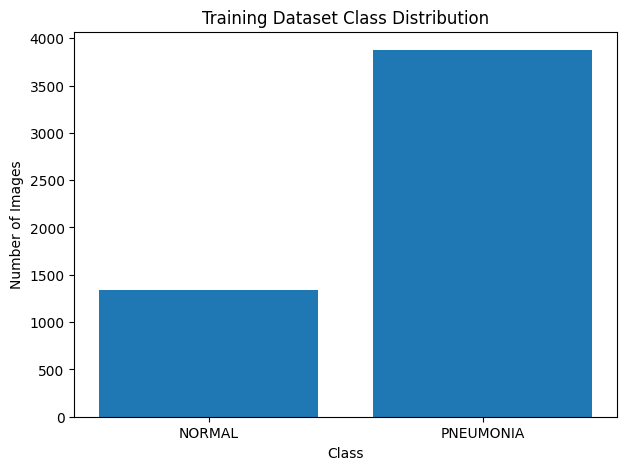

In [56]:
import matplotlib.pyplot as plt

train_normal = len(os.listdir(os.path.join(data_path, "train", "NORMAL")))
train_pneumonia = len(os.listdir(os.path.join(data_path, "train", "PNEUMONIA")))

labels = ["NORMAL", "PNEUMONIA"]
counts = [train_normal, train_pneumonia]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)
plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

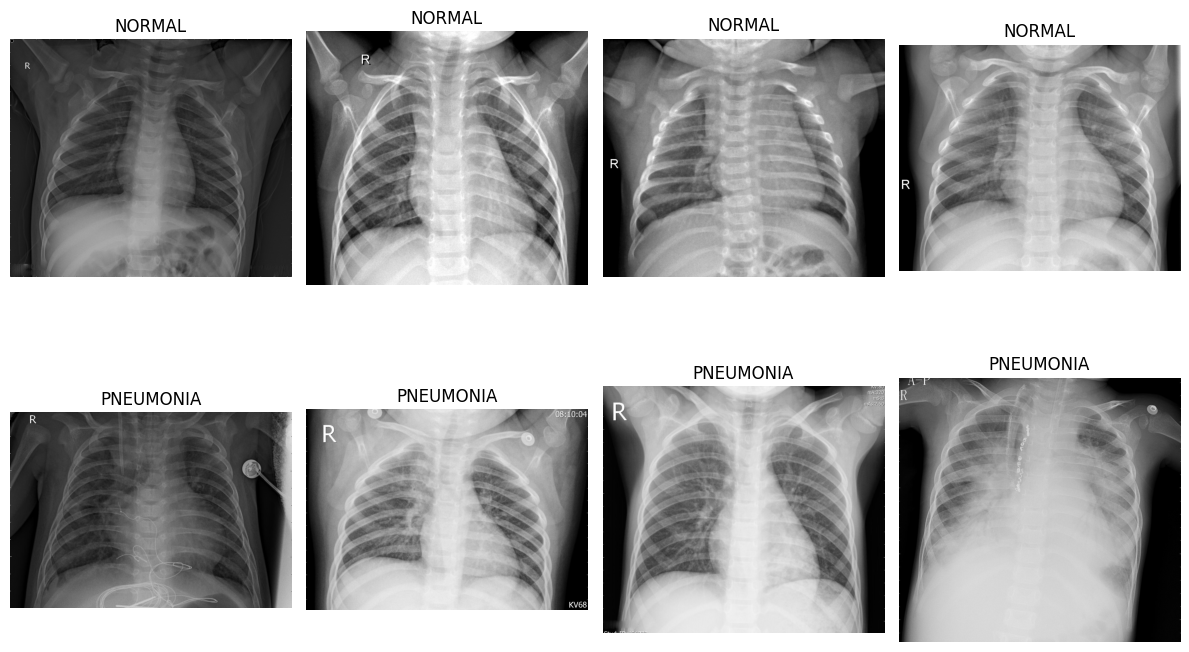

In [57]:
import matplotlib.pyplot as plt
from PIL import Image
import os

normal_path = os.path.join(data_path, "train", "NORMAL")
pneumonia_path = os.path.join(data_path, "train", "PNEUMONIA")

normal_files = os.listdir(normal_path)[:4]
pneumonia_files = os.listdir(pneumonia_path)[:4]

plt.figure(figsize=(12, 8))

for i, file in enumerate(normal_files):
    image = Image.open(os.path.join(normal_path, file))
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

for i, file in enumerate(pneumonia_files):
    image = Image.open(os.path.join(pneumonia_path, file))
    plt.subplot(2, 4, i + 5)
    plt.imshow(image, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
from PIL import Image
import os

# Check the first 10 NORMAL images
print("NORMAL images:")

for file in os.listdir(normal_path)[:10]:
    image = Image.open(os.path.join(normal_path, file))
    print(file, "→", image.size)

print("\nPNEUMONIA images:")

for file in os.listdir(pneumonia_path)[:10]:
    image = Image.open(os.path.join(pneumonia_path, file))
    print(file, "→", image.size)

NORMAL images:
NORMAL2-IM-0771-0001.jpeg → (1336, 1128)
NORMAL2-IM-1294-0001-0002.jpeg → (1400, 1260)
IM-0675-0001.jpeg → (1218, 1032)
NORMAL2-IM-1169-0001.jpeg → (1782, 1433)
IM-0421-0001.jpeg → (1574, 1129)
NORMAL2-IM-0531-0001.jpeg → (1744, 1345)
NORMAL2-IM-0416-0001-0002.jpeg → (1844, 1272)
NORMAL2-IM-0965-0001.jpeg → (1500, 1249)
NORMAL2-IM-0627-0001.jpeg → (2400, 2121)
NORMAL2-IM-0997-0001.jpeg → (1338, 1102)

PNEUMONIA images:
person1180_virus_2010.jpeg → (1024, 712)
person1230_virus_2081.jpeg → (1424, 1016)
person1513_virus_2632.jpeg → (1376, 1208)
person124_virus_238.jpeg → (1336, 1256)
person746_virus_1369.jpeg → (895, 516)
person588_bacteria_2422.jpeg → (1120, 656)
person466_virus_960.jpeg → (1084, 717)
person1590_bacteria_4175.jpeg → (2000, 1896)
person399_bacteria_1805.jpeg → (856, 568)
person59_bacteria_279.jpeg → (840, 488)


In [59]:
from PIL import Image
import os

def check_images(folder_path):
    corrupted = []

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except:
            corrupted.append(file)

    return corrupted


for folder in ["NORMAL", "PNEUMONIA"]:
    folder_path = os.path.join(data_path, "train", folder)

    bad_images = check_images(folder_path)

    print(folder, "corrupted images:", len(bad_images))

    if len(bad_images) > 0:
        print(bad_images[:10])

NORMAL corrupted images: 0
PNEUMONIA corrupted images: 0


In [60]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [63]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [64]:
train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 5216 files belonging to 2 classes.


In [65]:
print("Class names:", train_data.class_names)

for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)

Class names: ['NORMAL', 'PNEUMONIA']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 1)
Image data type: <dtype: 'float32'>


In [66]:
train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


In [67]:
val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [68]:
test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(data_path, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 624 files belonging to 2 classes.


In [69]:
print("Training batches:", tf.data.experimental.cardinality(train_data).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_data).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_data).numpy())

Training batches: 131
Validation batches: 33
Test batches: 20


In [73]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1)
])

In [74]:
print("Data augmentation created successfully.")

Data augmentation created successfully.


In [75]:
normal_count = 1341
pneumonia_count = 3875
total = normal_count + pneumonia_count

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * pneumonia_count)
}

print("Class weights:", class_weight)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [76]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("Base model loaded successfully.")

Base model loaded successfully.


In [77]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_422    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [78]:
import tensorflow as tf

data_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path + "/train",
    validation_split=0.2, subset="training", seed=42,
    image_size=(224, 224), batch_size=32,
    label_mode="binary", class_names=["NORMAL", "PNEUMONIA"],
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_path + "/train",
    validation_split=0.2, subset="validation", seed=42,
    image_size=(224, 224), batch_size=32,
    label_mode="binary", class_names=["NORMAL", "PNEUMONIA"],
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_path + "/test",
    image_size=(224, 224), batch_size=32,
    label_mode="binary", class_names=["NORMAL", "PNEUMONIA"],
    shuffle=False,
)

print("Training:", len(train_ds), "batches")
print("Validation:", len(val_ds), "batches")
print("Test:", len(test_ds), "batches")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
Training: 131 batches
Validation: 33 batches
Test: 20 batches


In [83]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1)
])

In [84]:
normal_count = 1341
pneumonia_count = 3875
total = normal_count + pneumonia_count
class_weight = {0: total / (2 * normal_count), 1: total / (2 * pneumonia_count)}
print(class_weight)

{0: 1.9448173005219984, 1: 0.6730322580645162}


In [85]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(224, 224, 3)
)
base_model.trainable = False
print("Base model loaded successfully.")

Base model loaded successfully.


In [95]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ],
)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_828    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [98]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.9336 - loss: 0.1666 - precision: 0.9808 - recall: 0.9283 - val_accuracy: 0.9271 - val_loss: 0.1907 - val_precision: 0.9918 - val_recall: 0.9118
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.9288 - loss: 0.1655 - precision: 0.9790 - recall: 0.9234 - val_accuracy: 0.9281 - val_loss: 0.1848 - val_precision: 0.9905 - val_recall: 0.9144
Epoch 3/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.9358 - loss: 0.1523 - precision: 0.9845 - recall: 0.9276 - val_accuracy: 0.9300 - val_loss: 0.1770 - val_precision: 0.9905 - val_recall: 0.9169
Epoch 4/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.9346 - loss: 0.1486 - precision: 0.9818 - recall: 0.9286 - val_accuracy: 0.9396 - val_loss: 0.1580 - val_precision: 0.9906 - val_recall: 0.9295
Epoch 5/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - accuracy: 0.9343 - loss: 0.1515 - precision: 0.9821 - recall: 0.9279 - val_accuracy: 0.9271

In [99]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y.numpy() for _, y in test_ds]).ravel()
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step
[[167  67]
 [ 18 372]]
              precision    recall  f1-score   support

      NORMAL       0.90      0.71      0.80       234
   PNEUMONIA       0.85      0.95      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.85       624
weighted avg       0.87      0.86      0.86       624



In [100]:
from sklearn.metrics import f1_score, recall_score, precision_score

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (y_prob > t).astype(int)
    print(f"t={t}  recall={recall_score(y_true,p):.3f}  "
          f"precision={precision_score(y_true,p):.3f}  "
          f"F1={f1_score(y_true,p):.3f}")

t=0.3  recall=0.972  precision=0.786  F1=0.869
t=0.4  recall=0.969  precision=0.825  F1=0.892
t=0.5  recall=0.954  precision=0.847  F1=0.897
t=0.6  recall=0.944  precision=0.868  F1=0.904
t=0.7  recall=0.931  precision=0.896  F1=0.913
t=0.8  recall=0.900  precision=0.916  F1=0.908


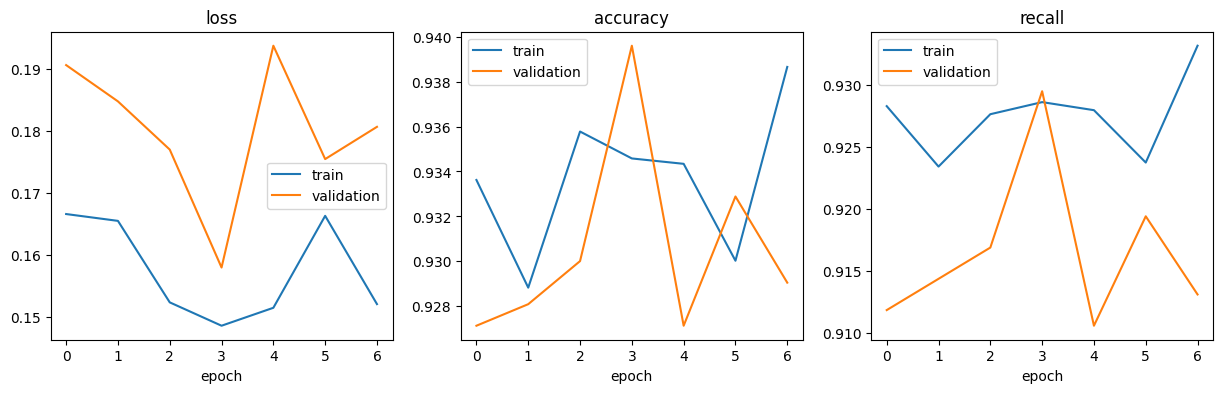

In [101]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, m in zip(ax, ["loss", "accuracy", "recall"]):
    a.plot(history.history[m], label="train")
    a.plot(history.history["val_" + m], label="validation")
    a.set_title(m)
    a.set_xlabel("epoch")
    a.legend()
plt.show()

In [102]:
def mc_predict(model, ds, n=20):
    preds = []
    for _ in range(n):
        batch_preds = []
        for x, _ in ds:
            feats = base_model(x, training=False)
            feats = tf.keras.layers.GlobalAveragePooling2D()(feats)
            feats = model.layers[-2](feats, training=True)  # dropout ON
            batch_preds.append(model.layers[-1](feats).numpy().ravel())
        preds.append(np.concatenate(batch_preds))
    return np.array(preds)

mc = mc_predict(model, test_ds)
mc_mean = mc.mean(axis=0)
mc_std = mc.std(axis=0)

mc_pred = (mc_mean > 0.5).astype(int)
print("MC recall:", recall_score(y_true, mc_pred))
print("Mean uncertainty (std):", mc_std.mean())

MC recall: 0.9615384615384616
Mean uncertainty (std): 0.051830865


In [104]:
wrong = (mc_pred != y_true)

print("Avg uncertainty when correct:", mc_std[~wrong].mean())
print("Avg uncertainty when wrong:  ", mc_std[wrong].mean())

# Flag the most uncertain 20% of images
cut = np.percentile(mc_std, 80)
unsure = mc_std >= cut
print("Error rate on confident images:", wrong[~unsure].mean())
print("Error rate on uncertain images:", wrong[unsure].mean())

Avg uncertainty when correct: 0.042575613
Avg uncertainty when wrong:   0.110520035
Error rate on confident images: 0.07414829659318638
Error rate on uncertain images: 0.384


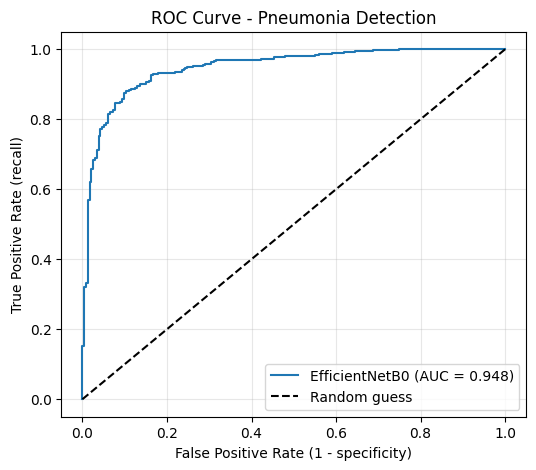

AUC: 0.9476002629848784


In [105]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"EfficientNetB0 (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate (1 - specificity)")
plt.ylabel("True Positive Rate (recall)")
plt.title("ROC Curve - Pneumonia Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("AUC:", auc)

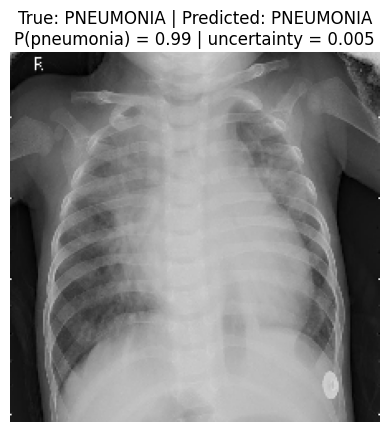

In [111]:
import random, glob
import numpy as np
import matplotlib.pyplot as plt

# Pick a random test image (change "NORMAL" to "PNEUMONIA" to choose the class)
true_class = random.choice(["NORMAL", "PNEUMONIA"])
files = glob.glob(f"{data_path}/test/{true_class}/*")
img_path = random.choice(files)

# Load and prepare it (no rescaling, EfficientNet handles that)
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
x = tf.keras.utils.img_to_array(img)[np.newaxis, ...]

# Normal prediction
prob = model.predict(x, verbose=0)[0][0]
label = "PNEUMONIA" if prob > 0.5 else "NORMAL"

# Monte Carlo uncertainty (20 runs)
one = tf.data.Dataset.from_tensor_slices((x, np.array([0]))).batch(1)
mc_one = mc_predict(model, one, n=20)
unc = mc_one.std()

plt.imshow(img)
plt.axis("off")
plt.title(f"True: {true_class} | Predicted: {label}\n"
          f"P(pneumonia) = {prob:.2f} | uncertainty = {unc:.3f}")
plt.show()
